Visualize what best fit parameters mean

In [1]:
import zeus21
from escripts import eMCMC
from escripts import edata
from escripts import eplots
import importlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
from astropy import units as u

In [192]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt',
             '/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt']
data_labels = ['Donnan+24', 'McLeod+24', 'Bouwens+21']
sorted_data = edata.get_sorted(file_names, data_labels, include_zs=[10, 11, 12.5])

Skipping $z = 4.0
Skipping $z = 5.0
Skipping $z = 6.0
Skipping $z = 7.0
Skipping $z = 8.0
Skipping $z = 9.0
Skipping $z = 13.5
Skipping $z = 14.5


In [193]:
params = eMCMC.build_param_data({'dsigdz': {'fit': False, 'value': 0}, 'dalphadz': {'fit': False, 'value':0}, 'dbetadz': 
                                 {'fit':False, 'value':0}, 'dlogedz': {'fit':False, 'value':0}, 'dlogMcdz':{'fit':False, 'value':0}})

In [194]:
my_UVLF = eMCMC.UVLF(sorted_data, params)

In [195]:
best_fit = [0.71, -0.54, 11.79, -0.81, 0.3, 3]

In [196]:
boosted_sig = [0.71, -0.54, 11.79, -0.81, 0.3, -0.4]

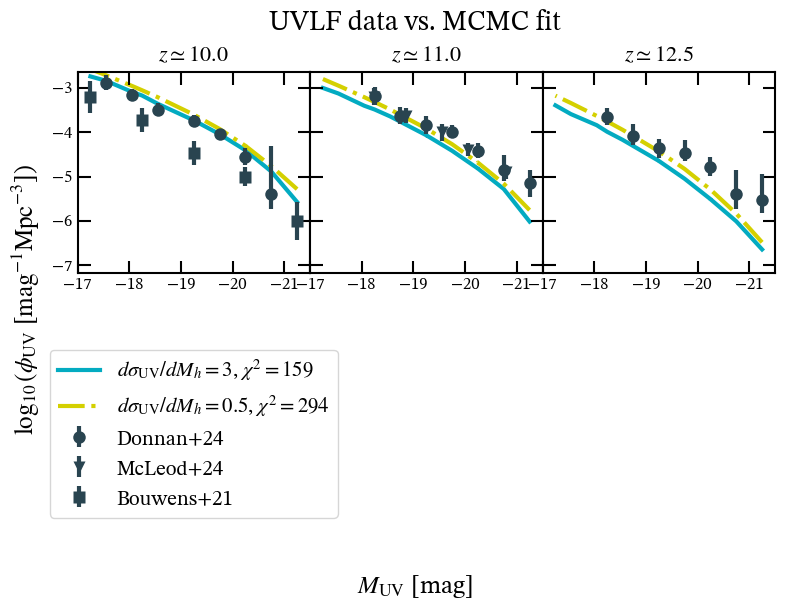

In [197]:
fig = eplots.evolving_UVLF_fit(my_UVLF, z_plot = [10, 11, 12.5], plot_from_chain = False, comparison_fits = [best_fit, boosted_sig], 
                               comparison_labels = [r'$d\sigma_{\rm{UV}}/dM_h = 3$', r'$d\sigma_{\rm{UV}}/dM_h = 0.5$'])

In [198]:
fig.savefig('/Users/eb35267/Desktop/code/figures/test_change_sig_deriv.png', bbox_inches='tight')

# $M_{\rm{UV}}$ Gaussians

In [80]:
87047009.24317743 / 1e7

8.704700924317743

In [85]:
importlib.reload(eplots)

<module 'escripts.eplots' from '/Users/eb35267/Desktop/code/home/escripts/eplots.py'>

52040964.23308811
[4.   3.74 3.48 3.22 2.96]
[0.3, -0.54, 11.79, -3.09, array([4.  , 3.74, 3.48, 3.22, 2.96])]


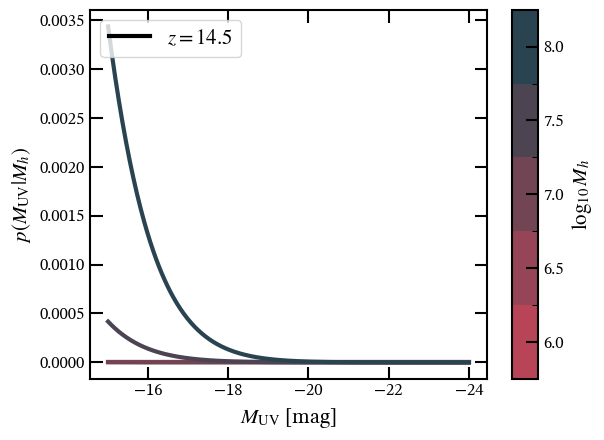

In [108]:
Mhtab = np.arange(6, 8.5, 0.5)
fig = eplots.MUV_distribution(my_UVLF, [14.5], best_fit, Mhtab)

In [87]:
test_UVLF = eMCMC.UVLF(sorted_data, params, cut_sig = True)

In [105]:
52040964.23308811/1e7

5.204096423308811

52040964.23308811
[1.00e-04 1.00e-04 1.00e-04 1.00e-04 2.96e+00]
[0.3, -0.54, 11.79, -3.09, array([1.00e-04, 1.00e-04, 1.00e-04, 1.00e-04, 2.96e+00])]


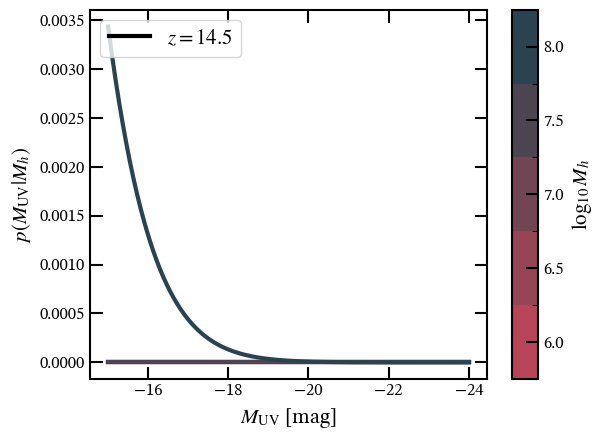

In [107]:
Mhtab = np.arange(6, 8.5, 0.5)
fig = eplots.MUV_distribution(test_UVLF, [14.5], best_fit, Mhtab)

# SFE($M_h$) for different $z$

In [22]:
def plot_sfe_evolution(my_UVLF, param_values, Mhtab, zmax, steps = 100):
    
    fig, ax = plt.subplots()
    cmap = LinearSegmentedColormap.from_list("custom", [eplots.red, eplots.navy])
    norm = BoundaryNorm(np.arange(min(Mhtab), max(Mhtab)+1, 1), cmap.N)

    zs = np.linspace(0, zmax, steps)

    for Mh in Mhtab:
        SFEs = np.zeros(steps)
        Mz = calc_Mz(zs, Mh, my_UVLF)
        for i, (z, Mz_i) in enumerate(zip(zs, Mz)):
            params = my_UVLF.time_evolution(param_values, z)
            Astro_Parameters = my_UVLF.param_wrapper(params)
                           
            SFEs[i] = zeus21.sfrd.fstarofz(Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mz_i)
        
        frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min())
        color = cmap(frac)
        ax.plot(zs, SFEs, color = color, ls = '-')

    # Color bar things:
    boundaries = np.arange(Mhtab.min()-0.5, Mhtab.max()+1.5, 1) # set bin edges between mass values
    norm = BoundaryNorm(boundaries, cmap.N)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=Mhtab, aspect = 14)
    cbar.set_label(r'$\log_{10}{M_h}$ at $z=0$')

    ax.set_ylabel(r'$\dot{M}_{\star} / f_b\dot{M}_h$')
    ax.set_xlabel('redshift')
    #ax.set_yscale('log')

    return fig

def calc_Mz(zs, M0, my_UVLF):
    steps = len(zs)
    Ms = np.zeros(steps+1)
    Ms[0] = 10**M0
    dz = (zs.max() - zs.min())/(steps+1)
    for i in range(steps):
        # Multiply dM/dt by dt/dz to get M_dot
        M_dot = calc_M_dot(Ms[i], zs[i], my_UVLF) /  ((1+zs[i]) * 
                                                      (zeus21.Hub(my_UVLF.CosmoParams, zs[i])*u.km/(u.s*u.Mpc)).to(u.year**-1).value) 
        # Had to take out a negative here to make it work; not sure why. Normally dt/dz would include a -(1+z)
        Ms[i+1] = Ms[i] - (M_dot * dz)

    return np.log10(Ms)

def calc_M_dot(M_h, z, my_UVLF):
    return 25.3*(M_h/1e12)**(1.1)*(1+(1.65*z))*np.sqrt((my_UVLF.CosmoParams.OmegaM*(1+z)**3)+my_UVLF.CosmoParams.OmegaL)

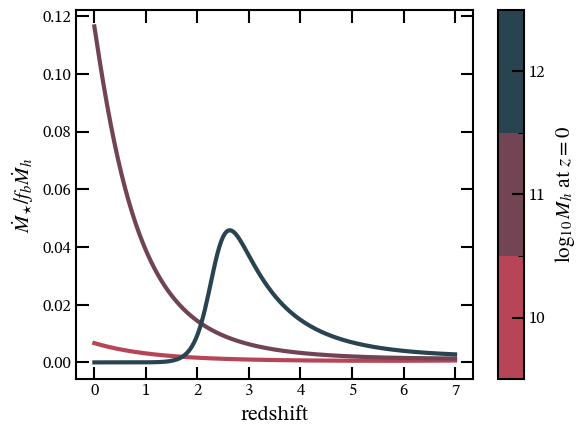

In [39]:
sfe_fig = plot_sfe_evolution(my_UVLF, best_fit, Mhtab, 7, 200)

In [40]:
def sfe_shape_diff_z(param_values, my_UVLF, Mhtab, zs):

    fig, ax = plt.subplots()
    cmap = LinearSegmentedColormap.from_list("custom", [eplots.turquoise, eplots.yellow])
    norm = BoundaryNorm(np.arange(min(zs), max(zs)+1, 1), cmap.N)
    
    for z in zs:
        params = my_UVLF.time_evolution(param_values, z)
        Astro_Parameters = my_UVLF.param_wrapper(params)
        SFEs = zeus21.sfrd.fstarofz(Astro_Parameters, my_UVLF.CosmoParams, z, 10**Mhtab)

        frac = (z - min(zs)) / (max(zs) - min(zs))
        color = cmap(frac)
        plt.plot(Mhtab, SFEs, color = color, ls = '-')


    # Color bar things:
    boundaries = np.arange(min(zs)-0.5, max(zs)+1.5, 1) # set bin edges between mass values
    norm = BoundaryNorm(boundaries, cmap.N)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=zs, aspect = 14)
    cbar.set_label(r'$z$')

    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$\dot{M}_{\star} / f_b\dot{M}_h$')
        
        
    return fig

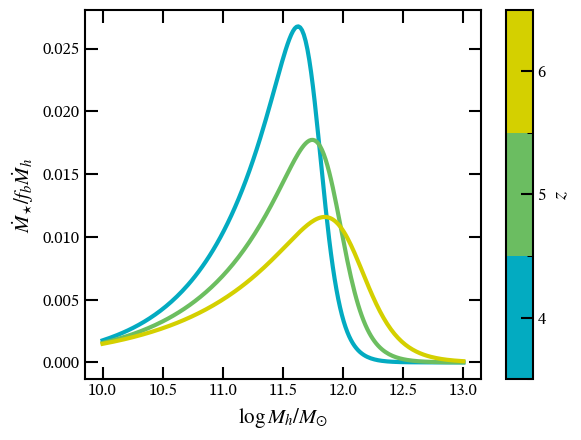

In [43]:
sfe_fig = sfe_shape_diff_z(best_fit, my_UVLF, Mhtab = np.linspace(10, 13, 200), zs = np.arange(4, 7, 1))

In [89]:
param_data = eMCMC.build_param_data({'dsigdz': {'fit': False, 'value': 0}, 'dalphadz': {'fit': False, 'value':0}, 
                                     'dbetadz': {'fit':False, 'value':0}, 'dlogedz': {'fit':False, 'value':0}, 
                                     'dlogMcdz':{'fit':False, 'value':0}})

In [144]:
my_UVLF = eMCMC.UVLF(sorted_data, param_data)

In [152]:
def sfe_shape_diff_fits(fits, fit_labels, my_UVLF, Mhtab):

    fig, ax = plt.subplots()
    
    for fit, fit_label in zip(fits, fit_labels):
        params = my_UVLF.time_evolution(fit, 0)
        Astro_Parameters = my_UVLF.param_wrapper(params)
        SFEs = zeus21.sfrd.fstarofz(Astro_Parameters, my_UVLF.CosmoParams, 0, 10**Mhtab)
        
        ax.plot(Mhtab, SFEs, label = fit_label)

    ax.set_xlabel(r'$\log{M_h/M_{\odot}}$')
    ax.set_ylabel(r'$\dot{M}_{\star} / f_b\dot{M}_h$')
    ax.legend()
    ax.set_yscale('log')
        
        
    return fig

In [153]:
fit_456 = [0.71, -0.54, 11.79, -0.81, 0.07, -0.61]
fit_789 = [0.78, -0.54, 11.79, -0.99, 0.23, -0.61]
fit_10plus = [0.3, -0.54, 11.79, -3.09, 1.4, -0.52]

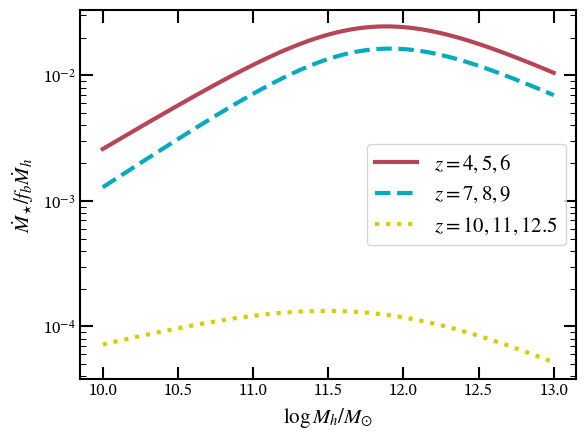

In [189]:
fig = sfe_shape_diff_fits([fit_456, fit_789, fit_10plus], [r'$z=4, 5, 6$', r'$z= 7, 8, 9$', r'$z=10, 11, 12.5$'],
                          my_UVLF, Mhtab = np.linspace(10, 13, 200))

In [190]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/sfe_comparison_narrowed_fixed.png', bbox_inches = 'tight')

In [213]:
def compare_MUV_distribution(my_UVLF, fits, fit_labels, Mhtab):
    fig, ax = plt.subplots()
    MUV_range = np.linspace(-15, -22, 500)
    ax.invert_xaxis()
    
    cmap = LinearSegmentedColormap.from_list("custom", [eplots.red, eplots.navy])
    dM = Mhtab[1]-Mhtab[0] # Separation between each halo mass
    norm = BoundaryNorm(np.arange(min(Mhtab), max(Mhtab)+dM, dM), cmap.N)
    
    my_UVLF.HMFintclass.Mhtab = 10**Mhtab 
    
    for fit, fit_label, ls in zip(fits, fit_labels, ['-', (0, (5, 1))]):
        #total_prob = np.zeros_like(MUV_range)
        params = my_UVLF.time_evolution(fit, 0)
        astroparams = my_UVLF.param_wrapper(params)
        SFRlist = zeus21.sfrd.SFR_II(astroparams, my_UVLF.CosmoParams, my_UVLF.HMFintclass, 10**Mhtab, 0, 0)
        MUVbarlist = zeus21.UVLFs.MUV_of_SFR(SFRlist, astroparams._kappaUV)
        MUVbarlist = np.fmin(MUVbarlist, zeus21.constants._MAGMAX)

        ax.plot(MUV_range[0], 0, ls = ls, color = 'black', label = fit_label) # Make invisible line for the legend purposes


        for sigUV, MUV_bar, Mh in zip(params[-1], MUVbarlist, Mhtab):
            frac = (Mh - Mhtab.min()) / (Mhtab.max() - Mhtab.min())
            color = cmap(frac)
            #prob = gaussian(MUV_range, sigUV, MUV_bar)
            #total_prob += prob
            ax.plot(MUV_range, gaussian(MUV_range, sigUV, MUV_bar), color = color, ls = ls)

        #plt.plot(MUV_range, total_prob, color = 'black', ls = ls)
        

    # Color bar things:
    boundaries = np.arange(Mhtab.min()-(dM/2), Mhtab.max()+(1.5*dM), dM) # set bin edges between mass values
    norm = BoundaryNorm(boundaries, cmap.N)
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, boundaries=boundaries, ticks=Mhtab, aspect = 14)
    cbar.set_label(r'$\log_{10}{M_h}$')

    ax.set_ylabel(r'$p(M_{\rm{UV}}|M_h)$')
    ax.set_xlabel(r'$M_{\rm{UV}}$ [mag]')
    ax.legend()
    ax.set_yscale('log')
    ax.set_ylim(1e-20, 10)
    

    return fig

In [7]:
fig = compare_MUV_distribution(my_UVLF, [fit_456, fit_10plus], [r'$z=4, 5, 6$', r'$z=10, 11, 12.5$'], 
                               Mhtab = np.arange(7, 9, 0.5))

NameError: name 'compare_MUV_distribution' is not defined

In [215]:
#fig.savefig('/Users/eb35267/Desktop/code/figures/MUV_comparison_narrowed_fixed.png')